<a href="https://colab.research.google.com/github/Torabiy/DMRing/blob/main/DMRing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Inverse Design of Microring Resonator-Based Glucose Biosensor Using AI Diffusion Models

---

**For the technical details, please refer to:**

- **Y. Torabi**, A. Ekhteraei, and B. Baraeinejad, *“Inverse Design of Microring Resonator-Based Glucose Biosensor Using AI Diffusion Models,”* **Optica Open (preprint), 2025.** [https://doi.org/10.1364/opticaopen.30525731](https://doi.org/10.1364/opticaopen.30525731)

- 🚨 **Accepted at <i>IEEE Silicon Photonics Conference (SiPhotonics) 2026</i> !** 🚨


## Abstract

Glucose detection is crucial for the diagnosis of diabetes. Microring resonator biosensors detect small refractive index changes. We utilize artificial intelligence (AI) diffusion models for the inverse design of sensor geometries that are consistent with target spectral responses, offering potential for the development of intelligent photonic biosensors.



#Section 1: Analytic Microring Resonance Simulation
This section analytically simulates the microring transmission spectrum and resonance wavelength shifts as a function of glucose-induced refractive index changes.

glucose=0.000  λ0=1.550841 µm  Δλ=+0.00 nm
glucose=0.167  λ0=1.550919 µm  Δλ=+0.08 nm
glucose=0.250  λ0=1.550957 µm  Δλ=+0.12 nm
glucose=0.300  λ0=1.550980 µm  Δλ=+0.14 nm


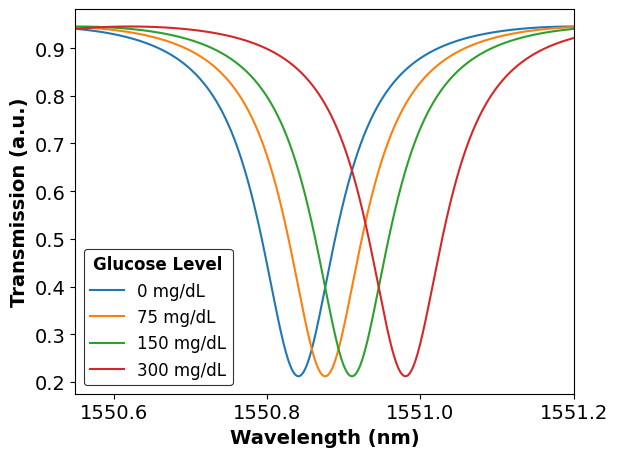

In [ ]:
"""
Analytic Microring Resonator Simulation

This script simulates the through-port transmission spectrum of an all-pass
microring resonator and computes resonance wavelength shifts (Δλ) as a function
of glucose-induced refractive index changes. The model is analytic and intended
for rapid evaluation and validation, complementary to full-wave simulations
(e.g., FDTD).

If you use this code or adapt it, please cite:
Y. Torabi, A. Ekhteraei, and B. Baraeinejad,
"Inverse Design of Microring Resonator-Based Glucose Biosensor Using AI Diffusion Models,"
Optica Open (preprint), 2025.
DOI: https://doi.org/10.1364/opticaopen.30525731


Copyright (c) 2025 Yasaman Torabi.
All rights reserved.
"""

from __future__ import annotations

import logging
from typing import Iterable

import numpy as np
import matplotlib.pyplot as plt

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# -----------------------------
# Plot styling (paper-like)
# -----------------------------
plt.rcParams.update(
    {
        "font.family": "Times New Roman",
        "font.size": 14,
        "axes.labelweight": "bold",
        "axes.titlesize": 16,
        "axes.titleweight": "bold",
        "legend.fontsize": 12,
    }
)

# -----------------------------
# Device geometry (units: µm)
# -----------------------------
R_UM = 400.0  # ring radius
W_UM = 2.8     # waveguide width
G_UM = 0.9     # ring-bus gap
L_UM = 2.0 * np.pi * R_UM  # ring round-trip length

# -----------------------------
# Optical wavelength grid (units: µm)
# -----------------------------
LAM_CENTER_UM = 1.5509
LAM_SPAN_UM = 0.0007
N_POINTS = 2001
LAM_UM = np.linspace(
    LAM_CENTER_UM - LAM_SPAN_UM / 2.0,
    LAM_CENTER_UM + LAM_SPAN_UM / 2.0,
    N_POINTS,
)

# -----------------------------
# Model parameters
# -----------------------------
NEFF0 = 1.3334     # baseline effective index (dimensionless)
DNEFF_DGLU = 4e-4  # effective index slope vs glucose (per unit glucose)
ALPHA_DB_CM = 5.0  # propagation loss (dB/cm)


def neff_from_glucose(glucose: float, neff0: float = NEFF0, slope: float = DNEFF_DGLU) -> float:

    return slope * glucose + neff0


def roundtrip_amplitude(alpha_db_cm: float, ring_length_um: float) -> float:

    # Convert dB/cm -> Np/µm:
    # 1 Np = 8.686 dB, so alpha_Np = alpha_dB / 8.686
    # Convert per cm -> per µm: 1 cm = 1e4 µm
    alpha_np_per_um = (alpha_db_cm / 8.686) / 1e4
    return float(np.exp(-alpha_np_per_um * ring_length_um))


def k_from_gap(gap_um: float) -> float:

    k = 200.0 * np.exp(-8.0 * (gap_um - 0.20))
    return float(np.clip(k, 0.0, 0.999999))


def spectrum_allpass(lam_um: np.ndarray, glucose: float, gap_um: float) -> np.ndarray:

    n_eff = neff_from_glucose(glucose)
    beta = 2.0 * np.pi * n_eff / lam_um  # rad/µm
    phi = beta * L_UM                    # round-trip phase (rad)

    a = roundtrip_amplitude(ALPHA_DB_CM, L_UM)
    k = k_from_gap(gap_um)
    t = np.sqrt(1.0 - k**2)              # self-coupling (field)

    num = t - a * np.exp(-1j * phi)
    den = 1.0 - a * t * np.exp(-1j * phi)
    return np.abs(num / den) ** 2


def resonance_wavelength(lam_um: np.ndarray, T: np.ndarray) -> float:

    idx = int(np.argmin(T))
    return float(lam_um[idx])


def print_shift_table(glucose_levels: Iterable[float], lam0_um: np.ndarray) -> None:

    baseline_um = lam0_um[0]
    dlam_nm = (lam0_um - baseline_um) * 1e3  # µm -> nm

    for g, l0, dl in zip(glucose_levels, lam0_um, dlam_nm):
        print(f"glucose={g:.3f}  λ0={l0:.6f} µm  Δλ={dl:+.2f} nm")


def plot_spectra(glucose_levels: Iterable[float]) -> None:

    for g in glucose_levels:
        plt.plot(LAM_UM, spectrum_allpass(LAM_UM, g, G_UM), label=f"{1000*g:.0f} mg/dL")

    ax = plt.gca()

    desired_ticks_um = [1.5506, 1.5508, 1.5510, 1.5512]
    ax.set_xticks(desired_ticks_um)
    ax.set_xticklabels([f"{t * 1000:.1f}" for t in desired_ticks_um])

    leg = plt.legend(title="Glucose Level", frameon=True, loc="lower left")
    leg.get_frame().set_edgecolor("k")
    leg.get_frame().set_linewidth(0.8)
    leg.set_title("Glucose Level", prop={"weight": "bold", "size": 12})

    plt.xlabel("Wavelength (nm)", fontweight="bold")
    plt.ylabel("Transmission (a.u.)")
    plt.xlim(1.55055, 1.5512)
    plt.grid(False)
    plt.tight_layout()
    plt.show()


def main() -> None:
    glucose_levels = [0.0, 0.167, 0.250, 0.300]
    lam0_list = []

    for g in glucose_levels:
        T = spectrum_allpass(LAM_UM, g, G_UM)
        lam0_list.append(resonance_wavelength(LAM_UM, T))

    lam0_um = np.array(lam0_list, dtype=float)
    print_shift_table(glucose_levels, lam0_um)
    plot_levels = [0.0, 0.075, 0.150, 0.300]
    plot_spectra(plot_levels)


if __name__ == "__main__":
    main()


#Section 2: Diffusion-Based Inverse Design of Microring Geometry
This section trains a diffusion model to generate 2D layouts of a microring resonator and bus waveguide.

100%|██████████| 20000/20000 [01:22<00:00, 243.37it/s]


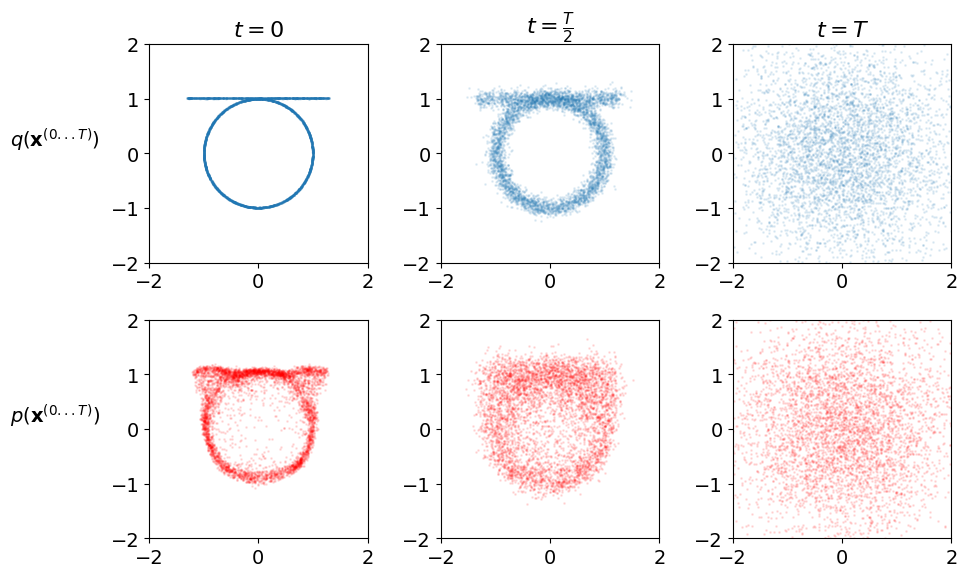


=== Photonic Validation (PHYSICAL UNITS) ===
Design target: R=400.000 µm, w=2.800 µm, g=0.900 µm
Chamfer distance (↓): 0.0393
Radius  R: real=500.080 µm, gen=481.917 µm,  |ΔR|/R = 3.63%
Width   w: real=3.129 µm, gen=3.440 µm,  |Δw|/w = 9.91%
Gap     g: real=-0.984 µm, gen=-0.992 µm,  |Δg|/g = 0.82%


In [ ]:
"""
Diffusion-Model Inverse Design for Microring Geometry

Trains a diffusion model to generate 2D layouts of a microring
resonator + bus waveguide, conditioned on a compact optical-response descriptor.

If you use this code or adapt it, please cite:
Y. Torabi, A. Ekhteraei, and B. Baraeinejad,
"Inverse Design of Microring Resonator-Based Glucose Biosensor Using AI Diffusion Models,"
Optica Open (preprint), 2025.
DOI: https://doi.org/10.1364/opticaopen.30525731


Copyright (c) 2025 Yasaman Torabi.
All rights reserved.

"""

import numpy as np
import torch
from torch import nn
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.spatial import cKDTree
import random

# --------------------------
# Reproducibility
# --------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

# --------------------------
# TARGET GEOMETRY (PHYSICAL UNITS, e.g., µm)
# --------------------------
R_TGT = 400.0   # µm
W_TGT = 2.8     # µm
G_TGT = 0.9     # µm

XY_SCALE = R_TGT


# --------------------------
# Optical-response descriptor (λc, Δλ) generator
# --------------------------
def spectral_targets_from_params(
    R=1.2,
    w=0.12,
    g=0.35,
    glucose=0.20,
    neff0=1.60,
    dneff_dglu=1.5e-4,
    lambda_ref_um=1.55,
):
    L = 2 * np.pi * R  # ring round-trip length (consistent units)

    n_eff = neff0 + dneff_dglu * glucose
    m = max(1, int(round((n_eff * L) / lambda_ref_um)))

    lambda_c_um = (n_eff * L) / m
    lambda_c_um *= (1.0 + 0.01 * (w - 0.12) - 0.005 * (g - 0.35))

    sensitivity_nm_per_unit = 1.8 + 0.3 * (0.35 - g)
    delta_lambda_nm = sensitivity_nm_per_unit * glucose

    return float(lambda_c_um), float(delta_lambda_nm)


# --------------------------
# Layout generator
# --------------------------
def sample_batch(
    size,
    R=1.2,
    w=0.12,
    g=0.35,
    p_bus=0.25,
    jitter=0.5,          # jitter in PHYSICAL units
    center=(0.0, 0.0),
    xy_scale=1.0,
):
    cx, cy = center
    n_bus = int(size * p_bus)
    n_ring = size - n_bus

    # Ring annulus
    theta = np.random.uniform(0, 2 * np.pi, n_ring)
    r_inner = R - w
    r = np.random.uniform(r_inner, R, n_ring)
    xr = cx + r * np.cos(theta) + np.random.normal(0, jitter, n_ring)
    yr = cy + r * np.sin(theta) + np.random.normal(0, jitter, n_ring)

    # Bus waveguide stripe (horizontal)
    bus_lower_y = cy + R + g
    bus_thick = w
    yb = np.random.uniform(bus_lower_y, bus_lower_y + bus_thick, n_bus)
    bus_half_span = (R + 0.3 * R)
    xb = np.random.uniform(cx - bus_half_span, cx + bus_half_span, n_bus)
    xb += np.random.normal(0, jitter, n_bus)
    yb += np.random.normal(0, jitter, n_bus)

    x = np.concatenate([xr, xb]).astype(np.float32)
    y = np.concatenate([yr, yb]).astype(np.float32)

    pts = np.stack([x, y], axis=1).astype(np.float32)

    # Normalize for stable learning
    pts /= float(xy_scale)
    return pts


def make_condition(
    size,
    R=1.2,
    w=0.12,
    g=0.35,
    glucose_range=(0.0, 0.30),
    lam_mu=1.55,
    lam_scale=0.02,
    dlam_mu=0.0,
    dlam_scale=2.0,
):
    glucose = np.random.uniform(*glucose_range)
    lam_c_um, dlam_nm = spectral_targets_from_params(R=R, w=w, g=g, glucose=glucose)
    c0 = np.array(
        [(lam_c_um - lam_mu) / lam_scale, (dlam_nm - dlam_mu) / dlam_scale],
        dtype=np.float32,
    )
    return np.repeat(c0[None, :], repeats=size, axis=0).astype(np.float32)


def sample_batch_with_condition(
    size,
    R=R_TGT,
    w=W_TGT,
    g=G_TGT,
    p_bus=0.25,
    jitter=0.5,              # PHYSICAL jitter (µm-ish)
    center=(0.0, 0.0),
    glucose_range=(0.0, 0.30),
    lam_mu=1.55,
    lam_scale=0.02,
    dlam_mu=0.0,
    dlam_scale=2.0,
    xy_scale=XY_SCALE,
):
    x0 = sample_batch(size, R=R, w=w, g=g, p_bus=p_bus, jitter=jitter, center=center, xy_scale=xy_scale)
    c = make_condition(
        size, R=R, w=w, g=g,
        glucose_range=glucose_range,
        lam_mu=lam_mu, lam_scale=lam_scale,
        dlam_mu=dlam_mu, dlam_scale=dlam_scale,
    )
    return x0, c


# --------------------------
# Neural network: per-point MLP with conditioning concatenation
# --------------------------
class MLP(nn.Module):
    def __init__(self, N=40, data_dim=2, cond_dim=2, hidden_dim=128):
        super().__init__()
        in_dim = data_dim + cond_dim

        self.network_head = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.network_tail = nn.ModuleList(
            [
                nn.Sequential(
                    nn.Linear(hidden_dim, hidden_dim),
                    nn.ReLU(),
                    nn.Linear(hidden_dim, data_dim * 2),  # outputs [mu, logvar]
                )
                for _ in range(N)
            ]
        )

    def forward(self, x, t: int, c):
        xc = torch.cat([x, c], dim=1)
        h = self.network_head(xc)
        return self.network_tail[t](h)


# --------------------------
# Diffusion model
# --------------------------
class DiffusionModel(nn.Module):
    def __init__(self, model: nn.Module, n_steps=40, device="cpu"):
        super().__init__()
        self.model = model
        self.device = device
        self.n_steps = n_steps

        betas = torch.linspace(-18, 10, n_steps)
        self.beta = torch.sigmoid(betas) * (3e-1 - 1e-5) + 1e-5
        self.alpha = 1.0 - self.beta
        self.alpha_bar = torch.cumprod(self.alpha, dim=0)

    def forward_process(self, x0, t):
        t = t - 1
        alpha_forward = self.alpha[t]
        alpha_cum = self.alpha_bar[t]
        xt = x0 * torch.sqrt(alpha_cum) + torch.randn_like(x0) * torch.sqrt(1.0 - alpha_cum)

        mu1_scl = torch.sqrt(alpha_cum / alpha_forward)
        mu2_scl = 1.0 / torch.sqrt(alpha_forward)
        cov1 = 1.0 - alpha_cum / alpha_forward
        cov2 = self.beta[t] / alpha_forward
        lam = 1.0 / cov1 + 1.0 / cov2

        mu = (x0 * mu1_scl / cov1 + xt * mu2_scl / cov2) / lam
        sigma = torch.sqrt(1.0 / lam)
        return mu, sigma, xt

    def reverse(self, xt, t, c):
        t = t - 1
        if t == 0:
            return None, None, xt

        mu, logvar = self.model(xt, t, c).chunk(2, dim=1)
        sigma = torch.sqrt(torch.exp(logvar))
        samples = mu + torch.randn_like(xt) * sigma
        return mu, sigma, samples

    def sample(self, size, c, device):
        x = torch.randn((size, 2), device=device)

        if c.dim() == 1:
            c_rep = c.unsqueeze(0).repeat(size, 1)
        else:
            c_rep = c

        samples = [x]
        for step in range(self.n_steps):
            _, _, x = self.reverse(samples[-1], self.n_steps - step, c_rep)
            samples.append(x)
        return samples


# --------------------------
# Training loop
# --------------------------
def train(model, optimizer, nb_epochs=20000, batch_size=6400, device="cpu"):
    losses = []
    for _ in tqdm(range(nb_epochs)):
        x0_np, c_np = sample_batch_with_condition(batch_size, R=400.0, w=2.8, g=0.9)
        x0 = torch.from_numpy(x0_np).float().to(device)
        c = torch.from_numpy(c_np).float().to(device)

        t = np.random.randint(2, model.n_steps + 1)
        mu_post, sig_post, xt = model.forward_process(x0, t)
        mu, sig, _ = model.reverse(xt, t, c)

        KL = (
            (torch.log(sig) - torch.log(sig_post))
            + (sig_post**2 + (mu_post - mu) ** 2) / (2 * sig**2)
            - 0.5
        )
        loss = KL.mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return losses


# --------------------------
# Geometry validation utilities
# --------------------------
def chamfer_distance(X, Y):
    treeX, treeY = cKDTree(X), cKDTree(Y)
    dXY, _ = treeX.query(Y, k=1)
    dYX, _ = treeY.query(X, k=1)
    return 0.5 * (dXY.mean() + dYX.mean())


def split_ring_bus(points):
    cx, cy = np.median(points[:, 0]), np.median(points[:, 1])
    r = np.sqrt((points[:, 0] - cx) ** 2 + (points[:, 1] - cy) ** 2)
    r_lo, r_hi = np.percentile(r, [20, 80])
    ring = points[(r >= r_lo) & (r <= r_hi)]
    bus = points[(r < r_lo) | (r > r_hi)]
    return ring, bus


def fit_circle(points):
    x, y = points[:, 0], points[:, 1]
    A = np.c_[x, y, np.ones_like(x)]
    b = -(x**2 + y**2)
    a, b_, c = np.linalg.lstsq(A, b, rcond=None)[0]
    xc, yc = -a / 2.0, -b_ / 2.0
    R = np.sqrt((a**2 + b_**2) / 4.0 - c)

    r = np.sqrt((x - xc) ** 2 + (y - yc) ** 2)
    R_in, R_out = np.percentile(r, [10, 90])
    w = 2*max(1e-8, R_out - R_in)/100
    return (xc, yc), R_out, w


def fit_bus_gap(bus_pts, center, R_out):
    y_low, y_high = np.percentile(bus_pts[:, 1], [5, 95])
    w_bus = 2*max(1e-8, y_high - y_low)/100
    xc, yc = center
    g_hat = (y_low - (yc + R_out))/1000
    return g_hat, w_bus


def photonic_metrics_from_points(points_norm, xy_scale=XY_SCALE):
    pts = points_norm * float(xy_scale)
    ring, bus = split_ring_bus(pts)
    center, R_out, w_hat = fit_circle(ring)
    g_hat, w_bus = fit_bus_gap(bus, center, R_out)
    return dict(center=center, R=R_out, w=w_hat, g=g_hat, w_bus=w_bus)


def photonic_validate(model, device="cpu", n_real=5000, n_gen=5000):
    X_real, C_real = sample_batch_with_condition(n_real, R=400, w=2.8, g=0.9)
    c0 = torch.from_numpy(C_real[0]).to(device)

    X_gen = model.sample(n_gen, c0, device)[-1].detach().cpu().numpy().astype(np.float32)

    chamfer = chamfer_distance(X_real, X_gen)

    geo_real = photonic_metrics_from_points(X_real)
    geo_gen = photonic_metrics_from_points(X_gen)

    rel = lambda a, b: 100.0 * abs(a - b) / max(1e-8, abs(b))
    dR = rel(geo_gen["R"], geo_real["R"])
    dw = rel(geo_gen["w"], geo_real["w"])
    dg = rel(geo_gen["g"], geo_real["g"])

    print("\n=== Photonic Validation (PHYSICAL UNITS) ===")
    print(f"Design target: R={R_TGT:.3f} µm, w={W_TGT:.3f} µm, g={G_TGT:.3f} µm")
    print(f"Chamfer distance (↓): {chamfer:.4f}")
    print(f"Radius  R: real={geo_real['R']:.3f} µm, gen={geo_gen['R']:.3f} µm,  |ΔR|/R = {dR:.2f}%")
    print(f"Width   w: real={geo_real['w']:.3f} µm, gen={geo_gen['w']:.3f} µm,  |Δw|/w = {dw:.2f}%")
    print(f"Gap     g: real={geo_real['g']:.3f} µm, gen={geo_gen['g']:.3f} µm,  |Δg|/g = {dg:.2f}%")

    return dict(chamfer=chamfer, dR=dR, dw=dw, dg=dg, real=geo_real, gen=geo_gen)


# --------------------------
# Visualization
# --------------------------
def plot_process(model, c, device="cpu", save_path="diffusion_model.pdf"):
    plt.figure(figsize=(10, 6))

    x0, _ = sample_batch_with_condition(5000)
    x0_t = torch.from_numpy(x0).to(device)

    x20 = model.forward_process(x0_t, 20)[-1].cpu().detach().numpy()
    x40 = model.forward_process(x0_t, 40)[-1].cpu().detach().numpy()
    data = [x0, x20, x40]

    for i, t in enumerate([0, 20, 39]):
        plt.subplot(2, 3, 1 + i)
        plt.scatter(data[i][:, 0], data[i][:, 1], alpha=0.1, s=1)
        plt.gca().set_aspect("equal")
        plt.xlim([-2, 2])
        plt.ylim([-2, 2])
        if t == 0:
            plt.ylabel(r"$q(\mathbf{x}^{(0...T)})$", fontsize=14, rotation=0, labelpad=40)
        plt.title(r"$t=0$" if i == 0 else (r"$t=\frac{T}{2}$" if i == 1 else r"$t=T$"))

    samples = model.sample(5000, c, device)
    for i, t in enumerate([0, 20, 40]):
        plt.subplot(2, 3, 4 + i)
        pts = samples[40 - t].cpu().detach().numpy()
        plt.scatter(pts[:, 0], pts[:, 1], alpha=0.1, s=1, c="r")
        plt.gca().set_aspect("equal")
        plt.xlim([-2, 2])
        plt.ylim([-2, 2])
        if t == 0:
            plt.ylabel(r"$p(\mathbf{x}^{(0...T)})$", fontsize=14, rotation=0, labelpad=40)

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()


# --------------------------
# Main
# --------------------------
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"

    model_mlp = MLP(hidden_dim=128, data_dim=2, cond_dim=2).to(device)
    model = DiffusionModel(model_mlp, n_steps=40, device=device)
    optimizer = torch.optim.Adam(model_mlp.parameters(), lr=1e-4)

    losses = train(model, optimizer, nb_epochs=20000, batch_size=6400, device=device)

    # Demo condition
    _, C_demo = sample_batch_with_condition(1)
    c_demo = torch.from_numpy(C_demo[0]).to(device)

    plot_process(model, c=c_demo, device=device, save_path="diffusion_model.pdf")

    results = photonic_validate(model, device=device, n_real=5000, n_gen=5000)


## Reference

If you use this code, please cite:

- Y. Torabi, A. Ekhteraei, and B. Baraeinejad, *“Inverse Design of Microring Resonator-Based Glucose Biosensor Using AI Diffusion Models,”* Optica Open (preprint), 2025. [https://doi.org/10.1364/opticaopen.30525731](https://doi.org/10.1364/opticaopen.30525731)


© 2025 by Yasaman Torabi. All rights reserved.